#aprendiendo SVM

Una Máquina de Vectores de Soporte (SVM, por sus siglas en inglés) es un algoritmo de aprendizaje automático supervisado utilizado principalmente para clasificación y regresión. Su objetivo es encontrar el mejor hiperplano (línea o frontera) que separa los datos en grupos, maximizando la distancia (margen) entre las clases

#Aspectos Clave de SVM:

##Funcionamiento:

Encuentra el hiperplano óptimo que maximiza el margen entre los puntos más cercanos de cada clase, conocidos como "vectores de soporte".


Aprendizaje Supervisado: Requiere datos etiquetados (entrenamiento) para construir el modelo.


Kernels (Núcleos): Puede manejar datos no lineales complejas transformándolos a dimensiones superiores mediante funciones kernel, permitiendo separar datos complejos.

Aplicaciones: Muy efectiva para clasificación de imágenes, detección de anomalías y problemas de clasificación binaria o multiclase.


Limitaciones: Puede ser lenta en conjuntos de datos muy grandes y es sensible al tipo de kernel seleccionado

In [ ]:
import pandas as pd

# Define the paths to your training and testing CSV files
# You can change these to your specific file names if needed
train_csv_path = '/content/sample_data/mnist_train_small.csv'
test_csv_path = '/content/sample_data/mnist_test.csv'

# Read the training CSV file into a DataFrame
try:
    train_df = pd.read_csv(train_csv_path)
    print(f"Training data loaded successfully from: {train_csv_path}")
    print("Shape of training data:", train_df.shape)
    print("First 5 rows of training data:")
    print(train_df.head())
except FileNotFoundError:
    print(f"Error: Training CSV file not found at {train_csv_path}")
except Exception as e:
    print(f"An error occurred while reading the training CSV: {e}")

print("\n" + "-" * 30 + "\n")

# Read the testing CSV file into a DataFrame
try:
    test_df = pd.read_csv(test_csv_path)
    print(f"Testing data loaded successfully from: {test_csv_path}")
    print("Shape of testing data:", test_df.shape)
    print("First 5 rows of testing data:")
    print(test_df.head())
except FileNotFoundError:
    print(f"Error: Testing CSV file not found at {test_csv_path}")
except Exception as e:
    print(f"An error occurred while reading the testing CSV: {e}")

Training data loaded successfully from: /content/sample_data/mnist_train_small.csv
Shape of training data: (19999, 785)
First 5 rows of training data:
   6  0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  ...  0.581  0.582  0.583  \
0  5  0    0    0    0    0    0    0    0    0  ...      0      0      0   
1  7  0    0    0    0    0    0    0    0    0  ...      0      0      0   
2  9  0    0    0    0    0    0    0    0    0  ...      0      0      0   
3  5  0    0    0    0    0    0    0    0    0  ...      0      0      0   
4  2  0    0    0    0    0    0    0    0    0  ...      0      0      0   

   0.584  0.585  0.586  0.587  0.588  0.589  0.590  
0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0  

[5 rows x 785 columns]

------------------------------

Testing dat

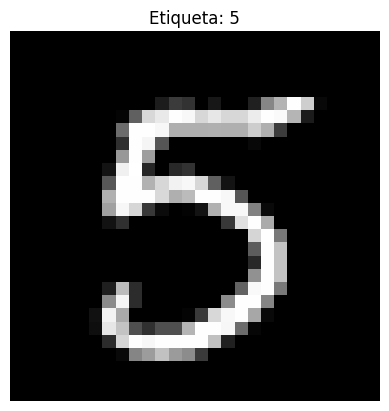

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Seleccionar la primera fila del DataFrame de entrenamiento para visualizar
# Asumimos que la primera columna es la etiqueta y el resto son píxeles
image_data = train_df.iloc[0]

# La primera columna es la etiqueta (el número que representa la imagen)
label = image_data.iloc[0]
# Las columnas restantes son los valores de los píxeles
pixel_values = image_data.iloc[1:].values

# Reshape los 784 píxeles a una matriz de 28x28 (para una imagen cuadrada)
image_matrix = pixel_values.reshape(28, 28)

# Mostrar la imagen
plt.imshow(image_matrix, cmap='gray') # Usamos un mapa de color gris
plt.title(f'Etiqueta: {label}')
plt.axis('off') # Ocultar los ejes para una mejor visualización de la imagen
plt.show()

### Preparación de Datos para SVM

Primero, dividiremos los DataFrames de entrenamiento y prueba en características (`X`) y etiquetas (`y`). Además, escalaremos los valores de los píxeles para que estén en un rango de 0 a 1, lo cual es beneficioso para el rendimiento de los modelos SVM.

In [ ]:
# Separar características (X) y etiquetas (y) para el conjunto de entrenamiento
X_train = train_df.iloc[:, 1:].values  # Todas las columnas excepto la primera (etiqueta)
y_train = train_df.iloc[:, 0].values   # La primera columna es la etiqueta

# Separar características (X) y etiquetas (y) para el conjunto de prueba
X_test = test_df.iloc[:, 1:].values    # Todas las columnas excepto la primera (etiqueta)
y_test = test_df.iloc[:, 0].values     # La primera columna es la etiqueta

# Escalar los valores de los píxeles para que estén en el rango [0, 1]
# Esto se hace dividiendo por 255, ya que los píxeles suelen estar en el rango [0, 255]
X_train = X_train / 255.0
X_test = X_test / 255.0

print(f"Shape de X_train: {X_train.shape}")
print(f"Shape de y_train: {y_train.shape}")
print(f"Shape de X_test: {X_test.shape}")
print(f"Shape de y_test: {y_test.shape}")

Shape de X_train: (19999, 784)
Shape de y_train: (19999,)
Shape de X_test: (9999, 784)
Shape de y_test: (9999,)


### Entrenamiento del Modelo SVM

Ahora, entrenaremos un modelo `LinearSVC` de Scikit-learn. Este es un tipo de SVM optimizado para grandes conjuntos de datos y que funciona bien con datos linealmente separables (o casi linealmente separables, como el MNIST después del escalado).

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

# Inicializar el modelo LinearSVC
# max_iter se aumenta para asegurar la convergencia en datasets grandes
# random_state para reproducibilidad
svm_model = LinearSVC(max_iter=1000, random_state=42)

print("Entrenando el modelo SVM... Esto puede tardar unos minutos.")
# Entrenar el modelo con los datos de entrenamiento escalados
svm_model.fit(X_train, y_train)

print("Modelo SVM entrenado exitosamente.")

Entrenando el modelo SVM... Esto puede tardar unos minutos.
Modelo SVM entrenado exitosamente.


### Evaluación del Modelo SVM

Una vez entrenado el modelo, haremos predicciones sobre el conjunto de prueba y calcularemos la precisión para ver qué tan bien se desempeña el modelo.

In [ ]:
# Realizar predicciones sobre el conjunto de prueba
y_pred = svm_model.predict(X_test)

# Calcular la precisión del modelo
accuracy = accuracy_score(y_test, y_pred)

print(f"La precisión del modelo LinearSVC en el conjunto de prueba es: {accuracy:.4f}")

La precisión del modelo LinearSVC en el conjunto de prueba es: 0.9058


### Probar el Modelo con una Imagen Individual

### Visualización del Proceso de Preparación de la Imagen para el Modelo

Vamos a detallar cómo una imagen se transforma de un conjunto de píxeles a la entrada que el modelo SVM espera. Esto incluye ver la forma de la imagen original, cómo se convierte en una matriz de 28x28 para visualización, y cómo se aplana a un vector de 1x784 para la predicción del modelo.

La etiqueta real de esta imagen es: 2
El modelo predice que esta imagen es un: 2


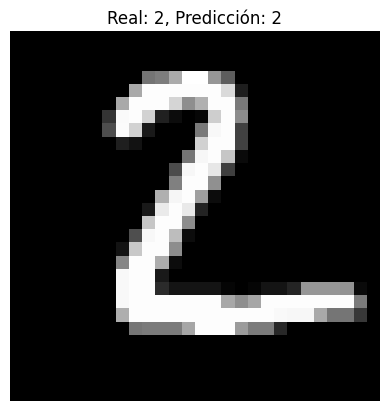

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Seleccionar una imagen de prueba (por ejemplo, la primera del conjunto de prueba)
image_to_test = X_test[0]
original_label = y_test[0] # La etiqueta real de esta imagen

# El modelo espera una entrada 2D (varias muestras, cada una con sus características)
# por lo que necesitamos 'reshapela' para que sea (1, 784) en lugar de (784,)
image_for_prediction = image_to_test.reshape(1, -1)

# Realizar la predicción
predicted_label = svm_model.predict(image_for_prediction)

print(f"La etiqueta real de esta imagen es: {original_label}")
print(f"El modelo predice que esta imagen es un: {predicted_label[0]}")

# Visualizar la imagen de prueba
plt.imshow(image_to_test.reshape(28, 28), cmap='gray')
plt.title(f'Real: {original_label}, Predicción: {predicted_label[0]}')
plt.axis('off')
plt.show()

Forma original de la imagen (vector 1D de píxeles): (784,)
Primeros 10 valores de píxeles de la imagen original:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Forma de la imagen para visualización (matriz 28x28): (28, 28)
Primeras 5x5 sub-matriz de la imagen para visualización:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

Forma de la imagen para la predicción del modelo (1 muestra, 784 características): (1, 784)
Primeros 10 valores de píxeles de la imagen para predicción:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

La etiqueta real de esta imagen es: 2
El modelo predice que esta imagen es un: 2



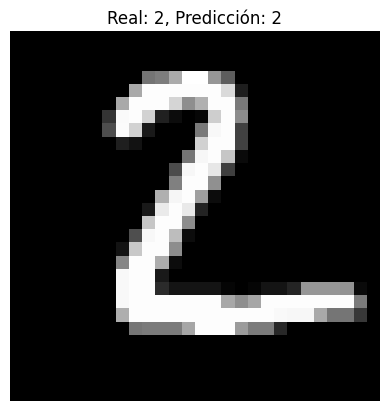

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Seleccionar una imagen de prueba (por ejemplo, la primera del conjunto de prueba)
image_to_test = X_test[0]
original_label = y_test[0] # La etiqueta real de esta imagen

print(f"Forma original de la imagen (vector 1D de píxeles): {image_to_test.shape}")
print(f"Primeros 10 valores de píxeles de la imagen original:\n{image_to_test[:10]}\n")

# Reshape para visualización (28x28)
image_matrix_display = image_to_test.reshape(28, 28)
print(f"Forma de la imagen para visualización (matriz 28x28): {image_matrix_display.shape}")
print(f"Primeras 5x5 sub-matriz de la imagen para visualización:\n{image_matrix_display[:5, :5]}\n")

# El modelo espera una entrada 2D (varias muestras, cada una con sus características)
# por lo que necesitamos 'reshapela' para que sea (1, 784) en lugar de (784,)
image_for_prediction = image_to_test.reshape(1, -1)

print(f"Forma de la imagen para la predicción del modelo (1 muestra, 784 características): {image_for_prediction.shape}")
print(f"Primeros 10 valores de píxeles de la imagen para predicción:\n{image_for_prediction[0, :10]}\n")

# Realizar la predicción
predicted_label = svm_model.predict(image_for_prediction)

print(f"La etiqueta real de esta imagen es: {original_label}")
print(f"El modelo predice que esta imagen es un: {predicted_label[0]}\n")

# Visualizar la imagen de prueba
plt.imshow(image_to_test.reshape(28, 28), cmap='gray')
plt.title(f'Real: {original_label}, Predicción: {predicted_label[0]}')
plt.axis('off')
plt.show()

### Predicción con Imágenes Capturadas desde la Cámara Web

Dado que el entorno de Colab no permite un acceso directo y continuo a la cámara web de manera sencilla para streaming, implementaremos una función que te permitirá tomar una "instantánea" (snapshot) desde tu cámara. Una vez que tengas la imagen, la preprocesaremos para que coincida con el formato de entrada esperado por nuestro modelo SVM (escala de grises, 28x28 píxeles y valores normalizados) y luego realizaremos una predicción.

In [ ]:
from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture Image';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

print("Función 'take_photo' definida. ¡Lista para capturar imágenes!")

Función 'take_photo' definida. ¡Lista para capturar imágenes!


A continuación, se activará tu cámara web. Verás un video y un botón 'Capture Image'.
Por favor, haz clic en 'Capture Image' cuando estés listo para tomar la foto del número.


<IPython.core.display.Javascript object>

Imagen capturada: photo.jpg


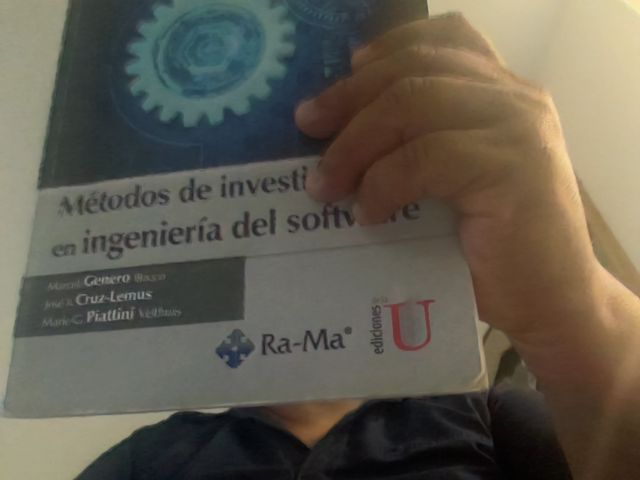

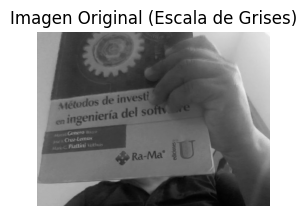

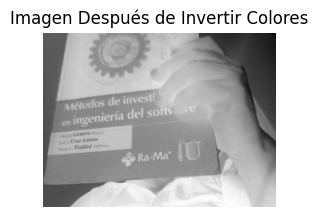

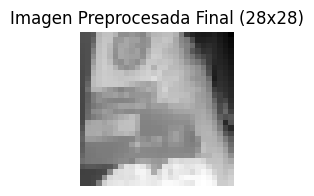

El modelo SVM predice que el número en la imagen es: 3


In [ ]:
import cv2

# 1. Capturar una imagen de la cámara web
try:
  print("A continuación, se activará tu cámara web. Verás un video y un botón 'Capture Image'.")
  print("Por favor, haz clic en 'Capture Image' cuando estés listo para tomar la foto del número.")
  filename = take_photo()
  print(f'Imagen capturada: {filename}')
  display(Image(filename))
except Exception as err:
  print(str(err))
  print('¡Error al capturar la imagen! Asegúrate de dar permiso a la cámara y vuelve a intentarlo.')
  print('Si el error persiste, puede que necesites subir una imagen manualmente.')

# Asegurarse de que la imagen fue capturada antes de intentar procesarla
if 'filename' in locals() and filename:
  # 2. Preprocesar la imagen capturada para el modelo SVM
  # Cargar la imagen en escala de grises
  img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

  if img is None:
      print("Error: No se pudo cargar la imagen. Revisa la ruta o el archivo.")
  else:
      # Mostrar la imagen original capturada en escala de grises
      plt.figure(figsize=(3,3))
      plt.imshow(img, cmap='gray')
      plt.title('Imagen Original (Escala de Grises)')
      plt.axis('off')
      plt.show()

      # Invertir colores si es necesario (MNIST tiene fondo negro, números blancos)
      # Puedes ajustar esto dependiendo de cómo dibujes el número
      img = cv2.bitwise_not(img) # Invierte blanco por negro y viceversa

      # Mostrar la imagen después de la inversión de colores
      plt.figure(figsize=(3,3))
      plt.imshow(img, cmap='gray')
      plt.title('Imagen Después de Invertir Colores')
      plt.axis('off')
      plt.show()

      # Redimensionar la imagen a 28x28 píxeles
      img_resized = cv2.resize(img, (28, 28), interpolation=cv2.INTER_AREA)

      # Normalizar los valores de píxeles a un rango de 0 a 1
      # Asegurarse de que el tipo de datos sea float antes de la división
      img_normalized = img_resized.astype('float32') / 255.0

      # Aplanar la imagen a un vector 1D de 784 píxeles
      # Y luego "reshapela" a (1, 784) para que el modelo lo acepte (1 muestra, 784 características)
      image_for_prediction_camera = img_normalized.reshape(1, -1)

      # Visualizar la imagen final preprocesada (28x28 normalizada)
      plt.figure(figsize=(2,2))
      plt.imshow(img_normalized, cmap='gray')
      plt.title('Imagen Preprocesada Final (28x28)')
      plt.axis('off')
      plt.show()

      # 3. Realizar la predicción con el modelo SVM entrenado
      predicted_label_camera = svm_model.predict(image_for_prediction_camera)

      # 4. Mostrar el resultado de la predicción
      print(f"El modelo SVM predice que el número en la imagen es: {predicted_label_camera[0]}")
else:
  print("No se pudo proceder porque no se capturó ninguna imagen.")

Notebook: Mi Primera Red Neuronal en Python
Objetivo: Comprender el flujo de datos desde la carga hasta la predicción.

1. El Kit de Herramientas (Importación)
Antes de construir, necesitamos las librerías adecuadas. En Python, estas son nuestras "cajas de herramientas".

In [ ]:
import pandas as pd # Para manejar tablas de datos
import numpy as np  # Para operaciones matemáticas avanzadas
import matplotlib.pyplot as plt # Para graficar resultados
from sklearn.model_selection import train_test_split # Para dividir datos
from sklearn.preprocessing import StandardScaler, LabelEncoder # Para limpieza
import tensorflow as tf # El "cerebro" de nuestra IA
from tensorflow.keras import layers, models # Componentes de la red

2. Preparación de los Datos (ETL)
Una IA es tan buena como los datos que recibe. Aquí cargamos el dataset y lo transformamos en números que la red pueda entender.

In [ ]:
# Cargamos el dataset desde una URL pública
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
columnas = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
data = pd.read_csv(url, names=columnas)

# Paso A: Convertir etiquetas de texto (Iris-setosa) a números (0, 1, 2)
encoder = LabelEncoder()
data['species'] = encoder.fit_transform(data['species'])

# Paso B: Separar características (X) de la respuesta que queremos (y)
X = data.drop('species', axis=1).values
y = data['species'].values

# Paso C: Dividir en Entrenamiento (80%) y Prueba (20%)
# Esto evita que la IA "memorice"; queremos que "aprenda".
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Paso D: Normalización (Poner todos los números en la misma escala)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

3. Arquitectura del Modelo
Aquí diseñamos la estructura de la red. Imagina que son capas de neuronas conectadas entre sí.

In [ ]:
model = models.Sequential([
    # Capa de entrada con 4 neuronas (una por cada medida de la flor)
    # 16 neuronas en la primera capa oculta con función de activación 'relu'
    layers.Dense(16, activation='relu', input_shape=(4,)),

    # Segunda capa oculta para encontrar patrones más complejos
    layers.Dense(8, activation='relu'),

    # Capa de salida: 3 neuronas (una por cada tipo de flor)
    # Usamos 'softmax' para obtener probabilidades (ej. 90% que sea la flor A)
    layers.Dense(3, activation='softmax')
])

# Compilación: Elegimos el optimizador (cómo mejora el modelo) y la métrica
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary() # Esto nos muestra el mapa de nuestra red

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

4. El Entrenamiento (Donde ocurre la magia)
Le pasamos los datos a la red varias veces (epochs) para que ajuste sus conexiones internas.

Entrenando el modelo...


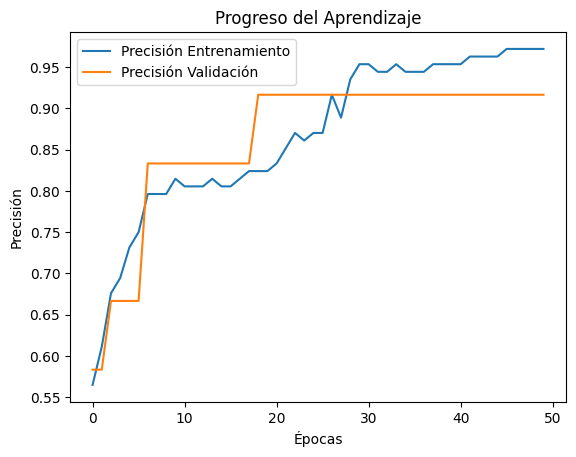

In [ ]:
print("Entrenando el modelo...")
history = model.fit(X_train, y_train, epochs=50, batch_size=5, verbose=0, validation_split=0.1)

# Grafiquemos el aprendizaje
plt.plot(history.history['accuracy'], label='Precisión Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión Validación')
plt.title('Progreso del Aprendizaje')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.show()

5. Evaluación y Predicción
Finalmente, probamos la IA con datos que nunca ha visto antes.

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nExactitud en datos de prueba: {accuracy*100:.2f}%")

# Hagamos una predicción manual
nueva_flor = np.array([[5.1, 3.5, 1.4, 0.2]]) # Medidas de una flor cualquiera
nueva_flor_escalada = scaler.transform(nueva_flor)
prediccion = model.predict(nueva_flor_escalada)
clase_final = np.argmax(prediccion)

print(f"La IA dice que esta flor es de tipo: {encoder.inverse_transform([clase_final])[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9667 - loss: 0.0999

Exactitud en datos de prueba: 96.67%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
La IA dice que esta flor es de tipo: Iris-setosa


video

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def start_camera():
  js = Javascript('''
    async function startCamera() {
      const div = document.createElement('div');
      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Botón para capturar y procesar
      const btn = document.createElement('button');
      btn.textContent = 'Capturar Frame y Procesar';
      div.appendChild(btn);

      return new Promise((resolve) => {
        btn.onclick = () => {
          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);
          stream.getVideoTracks()[0].stop();
          div.remove();
          resolve(canvas.toDataURL('image/jpeg'));
        };
      });
    }
    ''')
  display(js)
  data = eval_js('startCamera()')
  binary = b64decode(data.split(',')[1])
  return binary

2: Procesamiento de IA con OpenCV
Aquí es donde aplicas la lógica de ingeniería para detectar el color.

<IPython.core.display.Javascript object>

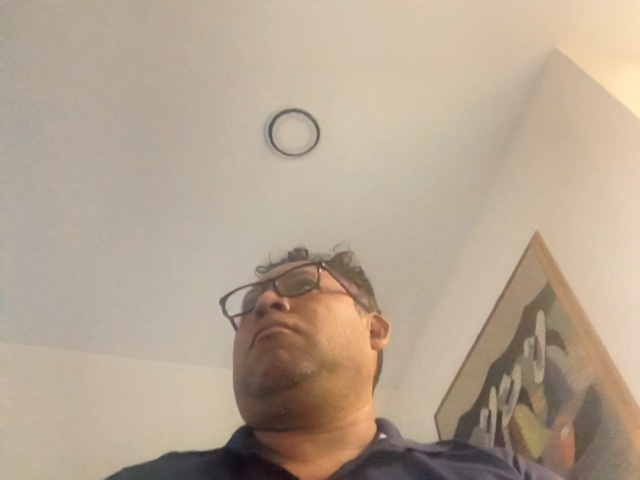

Procesamiento completado con éxito.


In [ ]:
import cv2
import numpy as np
from IPython.display import Image

try:
  # 1. Obtenemos la imagen de la cámara
  byte_image = start_camera()

  # 2. Convertimos bytes a imagen de OpenCV
  nparr = np.frombuffer(byte_image, np.uint8)
  frame = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

  # 3. Lógica de Detección (Filtro de Color)
  # Buscamos algo de color fuerte (ej. una libreta roja o azul)
  hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

  # Rango para detectar color AZUL (puedes ajustarlo)
  bajo_azul = np.array([100, 100, 20])
  alto_azul = np.array([125, 255, 255])

  mascara = cv2.inRange(hsv, bajo_azul, alto_azul)

  # Encontrar el objeto y dibujar un círculo encima
  contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

  if contornos:
      c = max(contornos, key=cv2.contourArea)
      if cv2.contourArea(c) > 500:
          x, y, w, h = cv2.boundingRect(c)
          cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 3)
          cv2.putText(frame, "Objeto Detectado", (x, y-10),
                      cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

  # 4. Guardar y mostrar el resultado
  cv2.imwrite('resultado.jpg', frame)
  display(Image('resultado.jpg'))
  print("Procesamiento completado con éxito.")

except Exception as err:
  print(f"Error: {err}")

<IPython.core.display.Javascript object>

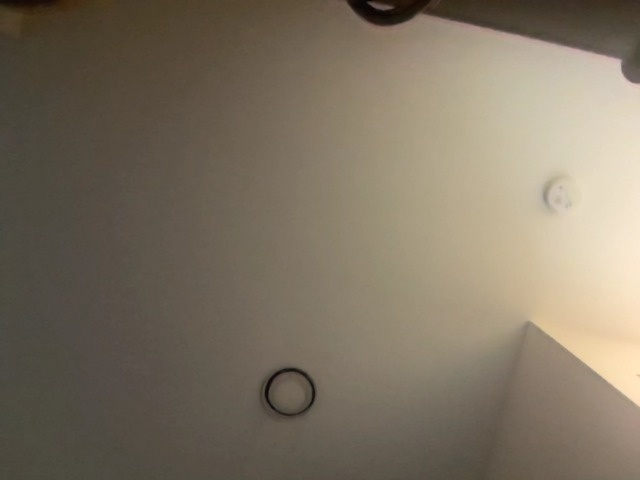

Procesamiento completado con éxito.


In [ ]:
import cv2
import numpy as np
from IPython.display import Image

try:
  # 1. Obtenemos la imagen de la cámara
  byte_image = start_camera()

  # 2. Convertimos bytes a imagen de OpenCV
  nparr = np.frombuffer(byte_image, np.uint8)
  frame = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

  # 3. Lógica de Detección (Filtro de Color)
  # Buscamos algo de color fuerte (ej. una libreta roja o azul)
  hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

  # Rango para detectar color AZUL (puedes ajustarlo)
  bajo_azul = np.array([100, 100, 20])
  alto_azul = np.array([125, 255, 255])

  mascara = cv2.inRange(hsv, bajo_azul, alto_azul)

  # Encontrar el objeto y dibujar un círculo encima
  contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

  if contornos:
      c = max(contornos, key=cv2.contourArea)
      if cv2.contourArea(c) > 500:
          x, y, w, h = cv2.boundingRect(c)
          cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 3)
          cv2.putText(frame, "Objeto Detectado", (x, y-10),
                      cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

  # 4. Guardar y mostrar el resultado
  cv2.imwrite('resultado.jpg', frame)
  display(Image('resultado.jpg'))
  print("Procesamiento completado con éxito.")

except Exception as err:
  print(f"Error: {err}")

Iniciando interfaz de cámara...
Sostén un objeto azul frente a la cámara y presiona el botón.


<IPython.core.display.Javascript object>

Procesando imagen con OpenCV...

--- RESULTADO PROCESADO ---
✅ Objeto detectado e identificado.


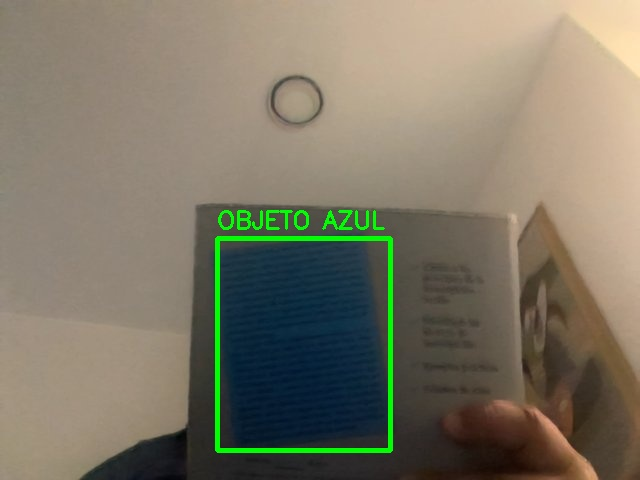

In [ ]:
import cv2
import numpy as np
from google.colab.output import eval_js
from base64 import b64decode, b64encode
from IPython.display import display, HTML, Image

# 1. FUNCIÓN JAVASCRIPT: Crea la interfaz de cámara en el navegador
# Retorna la imagen capturada en formato base64.
def capturar_foto_js():
  js = Javascript('''
    async function tomarFoto() {
      // Crear elementos HTML para la interfaz
      const div = document.createElement('div');
      div.style.border = '2px solid black';
      div.style.padding = '10px';
      div.style.width = 'max-content';

      const video = document.createElement('video');
      video.style.display = 'block';
      video.style.transform = 'scaleX(-1)'; // Efecto espejo para el usuario

      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Botón de acción
      const btn = document.createElement('button');
      btn.textContent = '📸 Capturar y Ver Detección';
      btn.style.display = 'block';
      btn.style.width = '100%';
      btn.style.marginTop = '10px';
      btn.style.padding = '10px';
      btn.style.cursor = 'pointer';
      div.appendChild(btn);

      // Esperar a que el usuario haga clic
      await new Promise((resolve) => btn.onclick = resolve);

      // Dibujar el frame actual en un canvas oculto para extraer los bytes
      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      // Dibujamos sin espejo para que OpenCV procese la imagen real
      canvas.getContext('2d').drawImage(video, 0, 0);

      // Limpieza: apagar cámara y quitar elementos
      stream.getVideoTracks()[0].stop();
      div.remove();

      // Retornar la imagen como string base64
      return canvas.toDataURL('image/jpeg', 0.85);
    }
    ''')
  display(js)
  data = eval_js('tomarFoto()')
  return data

# 2. FUNCIÓN PYTHON: Decodifica, procesa con IA y muestra
def procesar_y_mostrar_resultado(b64_string):
  try:
    # A. Decodificar la imagen base64 a bytes de imagen
    header, encoded = b64_string.split(',')
    image_bytes = b64decode(encoded)

    # B. Convertir bytes a formato Matriz de OpenCV (BGR)
    nparr = np.frombuffer(image_bytes, np.uint8)
    frame = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

    if frame is None:
        print("Error: No se pudo decodificar la imagen.")
        return

    # -----------------------------------------------------------
    # C. LÓGICA DE VISIÓN COMPUTACIONAL (Detección de Color)
    # -----------------------------------------------------------

    # Convertir a espacio de color HSV (mejor para detección)
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # Rango para detectar color AZUL fuerte
    bajo_azul = np.array([100, 100, 20])
    alto_azul = np.array([130, 255, 255])

    # Crear máscara binaria
    mascara = cv2.inRange(hsv, bajo_azul, alto_azul)

    # Limpieza de ruido (apertura morfológica)
    kernel = np.ones((5,5),np.uint8)
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel)

    # Encontrar contornos
    contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    detector_count = 0
    if contornos:
        # Suponemos que el contorno más grande es nuestro objeto
        c = max(contornos, key=cv2.contourArea)

        # Filtro de área mínima (para ignorar puntitos)
        if cv2.contourArea(c) > 1000:
            # Obtener rectángulo delimitador
            x, y, w, h = cv2.boundingRect(c)

            # DIBUJAR EN LA IMAGEN ORIGINAL
            # Cuadro verde (BGR: 0, 255, 0), grosor 3
            cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 3)

            # Texto de etiqueta
            cv2.putText(frame, "OBJETO AZUL", (x, y-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
            detector_count = 1

    # -----------------------------------------------------------
    # D. MOSTRAR EL RESULTADO FINAL
    # -----------------------------------------------------------

    # Guardar la imagen procesada temporalmente
    output_filename = 'resultado_final.jpg'
    cv2.imwrite(output_filename, frame)

    # Mostrar la imagen en la salida de Colab
    print("\n--- RESULTADO PROCESADO ---")
    if detector_count > 0:
        print("✅ Objeto detectado e identificado.")
    else:
        print("❌ No se detectó suficiente color azul en el rango establecido.")

    display(Image(output_filename))

  except Exception as e:
    print(f"Ocurrió un error en el procesamiento: {e}")

# --- FLUJO PRINCIPAL ---
from IPython.display import Javascript

print("Iniciando interfaz de cámara...")
# Paso 1: JS captura la foto
print("Sostén un objeto azul frente a la cámara y presiona el botón.")
imagen_b64 = capturar_foto_js()

# Paso 2: Python procesa y muestra automáticamente
print("Procesando imagen con OpenCV...")
procesar_y_mostrar_resultado(imagen_b64)